# Deconvolve the origins of replication

October 22, 2024

## Goal:
Collect the origins of replication from the known Belsky list. Track the -1 and +1. Show that the change in NFR size is associated with G1 to S transition.

Possible ideas:
- How does this change with respect to efficiency and early/late replication timing?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [351]:
from src.Figure3_Deconvolved_Origins import Figure4DeconvolvedOrigins

origins_analysis = Figure4DeconvolvedOrigins()

In [352]:
origins_analysis.load_origin()

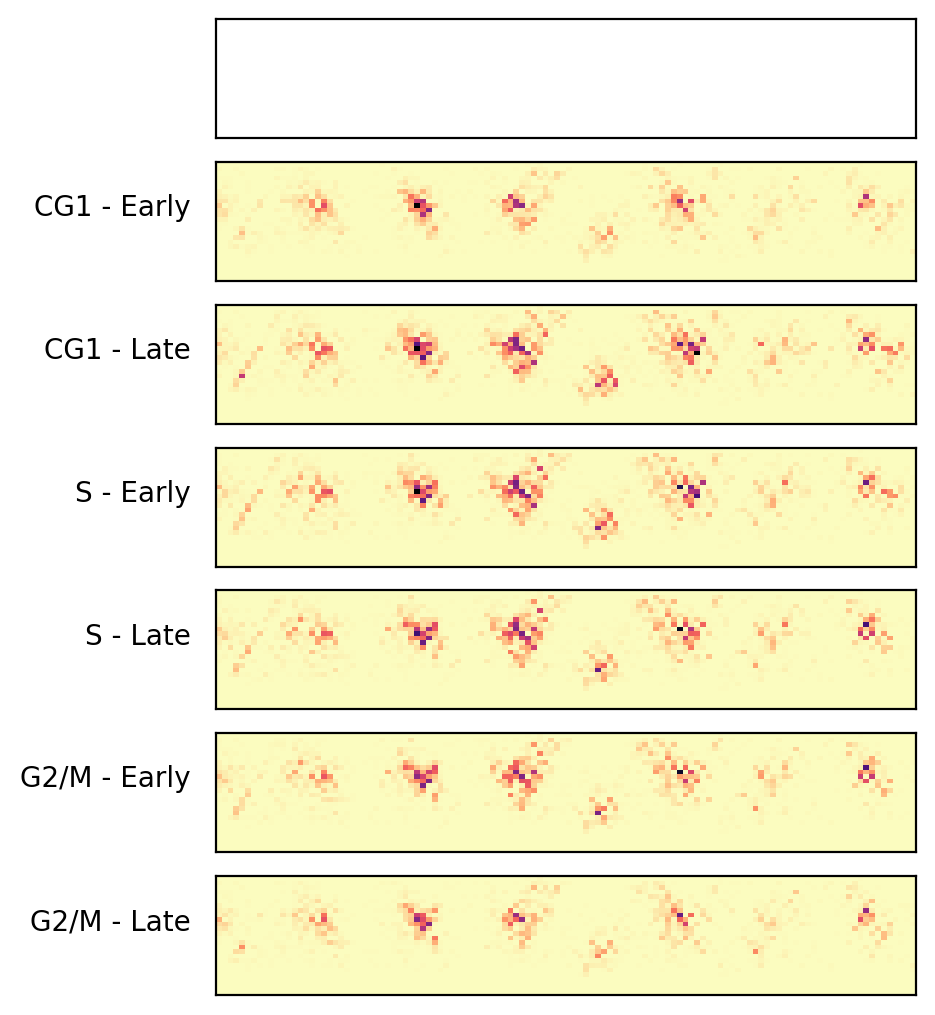

In [354]:
origins_analysis.plot_loaded_origin()

In [361]:
origins_analysis.track_nfr()

In [371]:
m1_track = origins_analysis.m1_track
p1_track = origins_analysis.p1_track

In [595]:
from src.timer import Timer

timer = Timer()

all_occs_df = pd.DataFrame()
all_m1s_df = pd.DataFrame()
all_p1s_df = pd.DataFrame()

for oridb, origin in origins_analysis.origins.iterrows():
    
    origins_analysis.load_origin(origin)
    origins_analysis.track_nfr()
    m1_track = origins_analysis.m1_track
    p1_track = origins_analysis.p1_track
    occ_track = origins_analysis.origin_occ
    m1_df = pd.DataFrame(m1_track, columns=[oridb]).T
    p1_df = pd.DataFrame(p1_track, columns=[oridb]).T
    occ_df = pd.DataFrame(occ_track, columns=[oridb]).T

    all_occs_df = pd.concat([all_occs_df, occ_df])
    all_m1s_df = pd.concat([all_m1s_df, m1_df])
    all_p1s_df = pd.concat([all_p1s_df, p1_df])

timer.print_time()

00:00:52.660


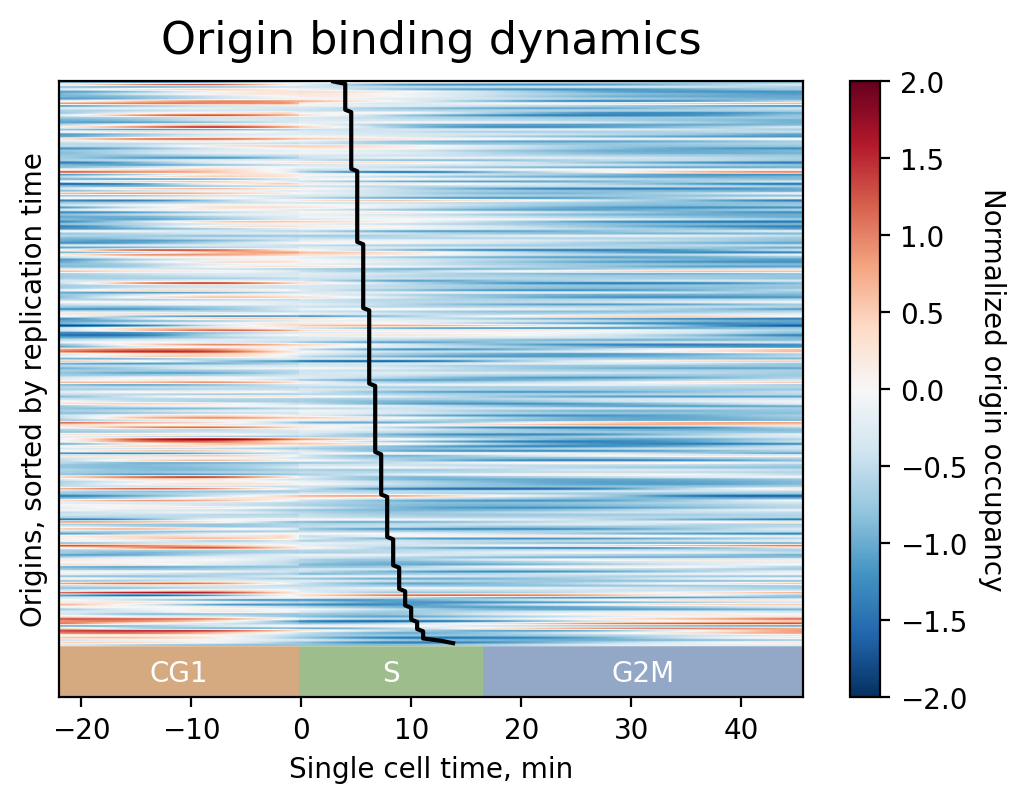

In [827]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

origins_analysis.plot_heatmap_occupancy(all_occs_df)
save_figure_for_paper("output/figures/Origin_Deconvolution/Origin_occupancy_heatmap.png")

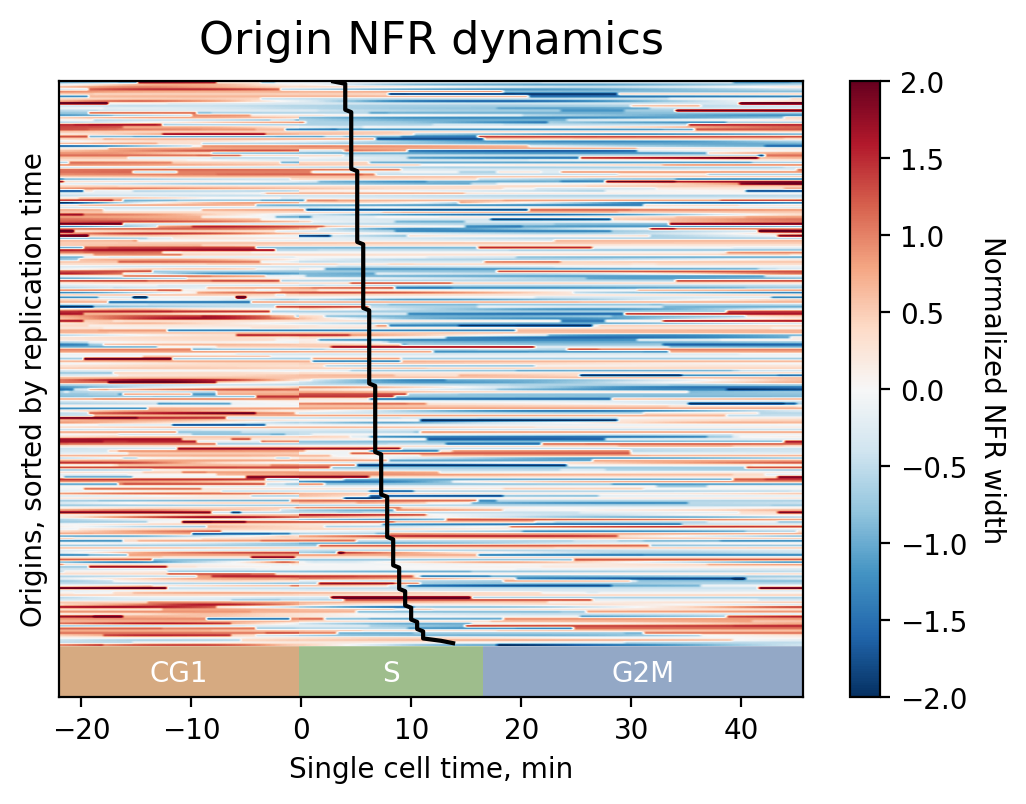

In [828]:
origins_analysis.plot_heatmap_nfr(all_p1s_df, all_m1s_df)
save_figure_for_paper('output/figures/Origin_Deconvolution/Origin_NFR_heatmap.png')

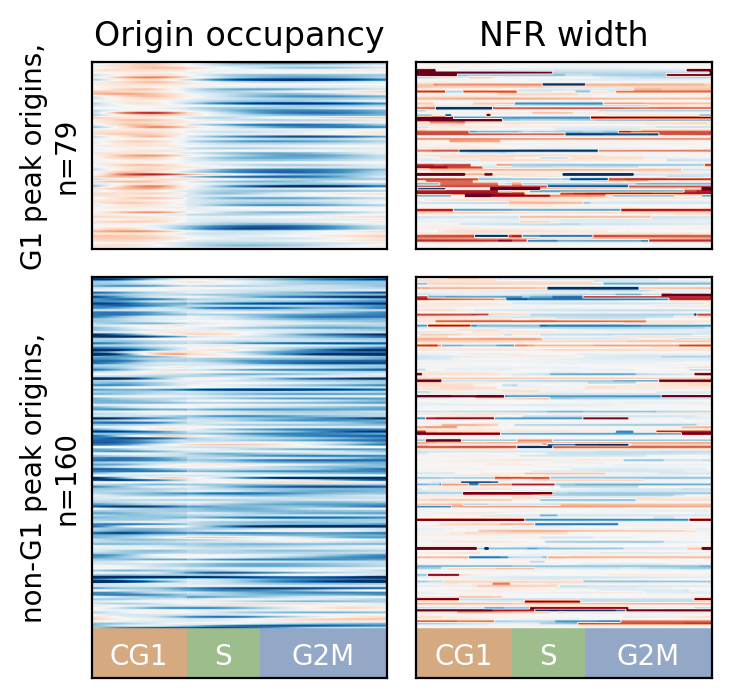

In [777]:
origins_analysis.plot_occupancy_partition_hm(normalized_occs, sorted_origins)
# We identified 80 origins in which the maximal occupancy of origin binding occurs in G1.
# for these origins, the NFR shows a greater increase in width than all other origins.
save_figure_for_paper('output/figures/Origin_Deconvolution/Origin_occupancy_NFR_segmented_heatmap.png')

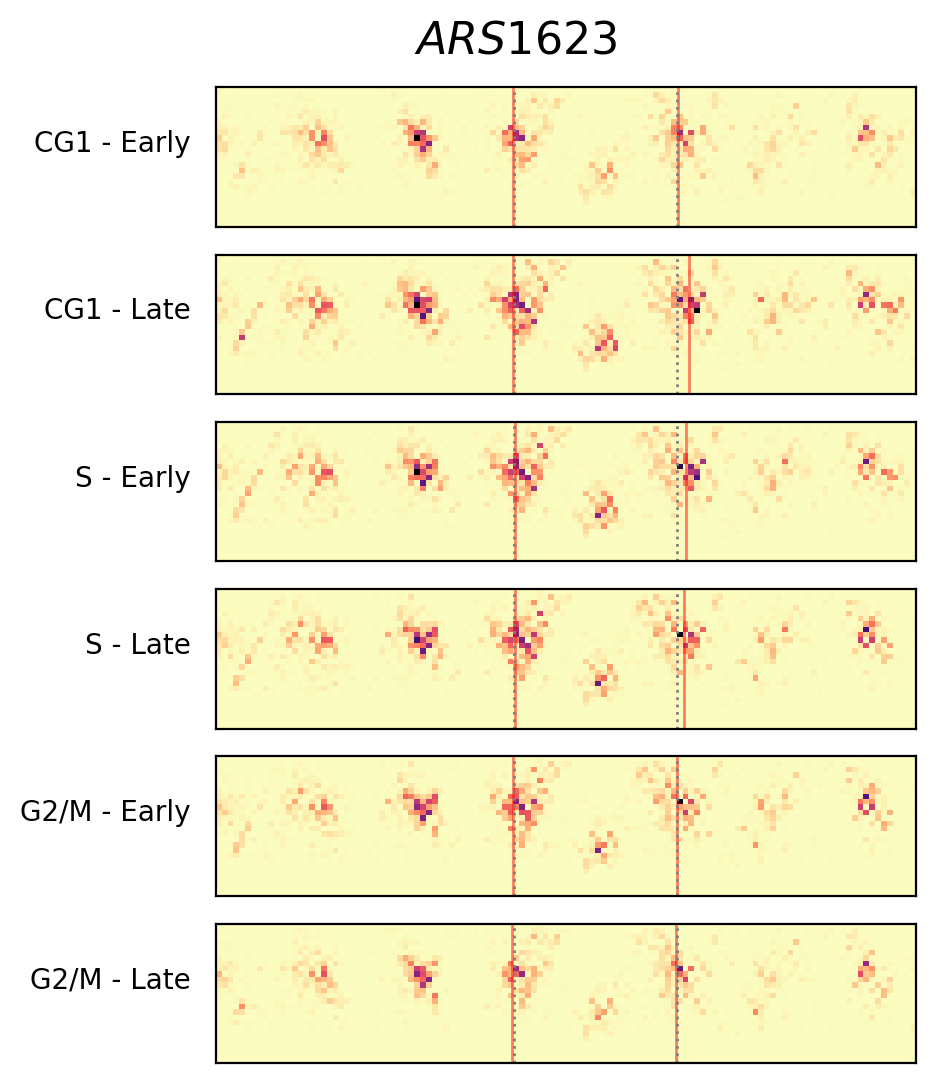

In [822]:
origins_analysis.load_origin()
origins_analysis.track_nfr()
origins_analysis.plot_loaded_origin()
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS1623_Example_chromatin.png')

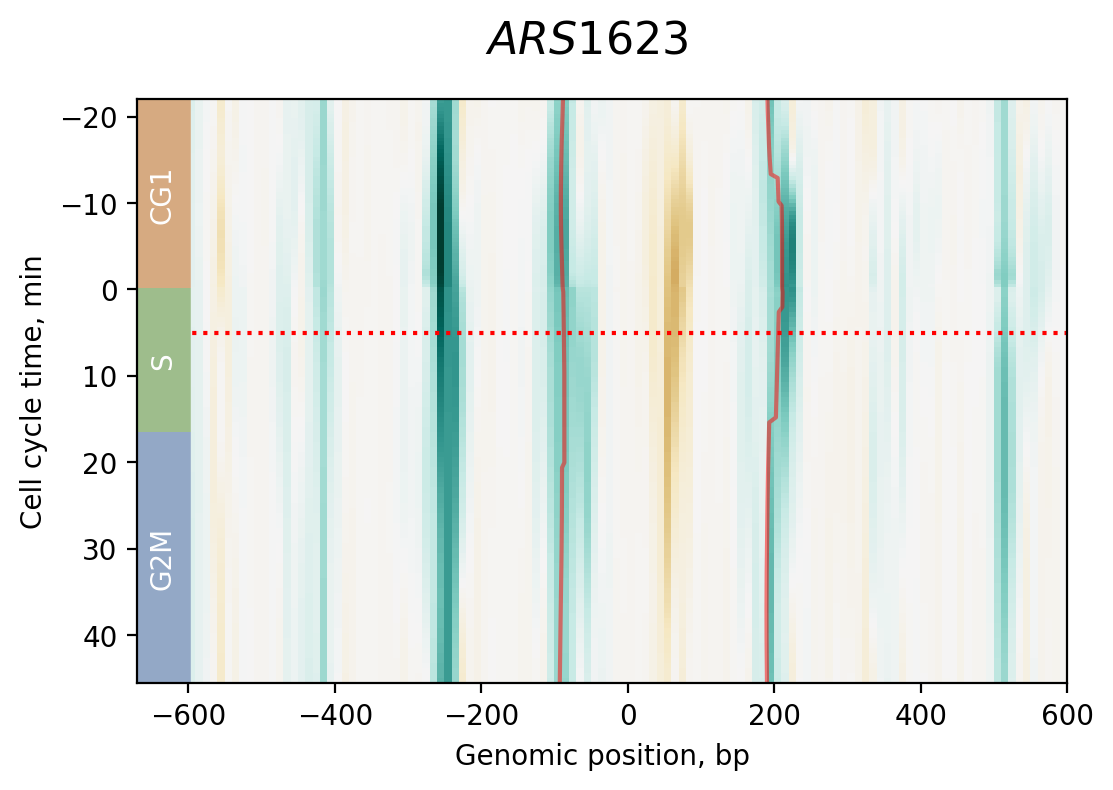

In [824]:
origins_analysis.plot_tracking_summary_hm()
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS1623_summary_chromatin.png')